# Tại sao chọn Best Epoch này?

Notebook này chứng minh bằng số liệu và biểu đồ tại sao checkpoint tại **best epoch** được lựa chọn thay vì epoch cuối cùng.

**Câu hỏi điển hình từ giảng viên:**
- Tại sao không chọn epoch cuối?
- Tại sao chọn epoch 58 (hoặc epoch nào đó)?
- Epoch đó tốt hơn epoch trước/sau ở đâu?
- Model có overfitting không?

> Mọi số liệu đều được đọc trực tiếp từ artifacts — **không hardcode**.


## Section 1 — Import Thư Viện & Định Nghĩa Đường Dẫn

In [25]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import torch

# ============================================================
# Style chung cho bảng báo cáo — tương thích dark/light theme
# Định nghĩa một lần tại đây, dùng lại cho mọi bảng pandas Styler
# ============================================================
REPORT_TABLE_STYLES = [
    {
        "selector": "caption",
        "props": (
            "caption-side: top;"
            "font-size: 15px;"
            "font-weight: bold;"
            "text-align: left;"
            "margin-bottom: 8px;"
            "color: #f8f9fa;"
        ),
    },
    {
        "selector": "th",
        "props": (
            "background-color: #343a40;"
            "color: #ffffff;"
            "font-weight: bold;"
            "padding: 8px 12px;"
            "text-align: center;"
            "border: 1px solid #495057;"
        ),
    },
    {
        "selector": "td",
        "props": (
            "padding: 8px 12px;"
            "border: 1px solid #495057;"
            "font-size: 13px;"
            "color: #f8f9fa;"
            "text-align: center;"
        ),
    },
]

# Màu highlight chuẩn — BẮT BUỘC kèm color:#000000 khi dùng nền sáng
STYLE_SELECTED = "background-color:#cfe2ff; color:#000000; font-weight:bold;"
STYLE_BEST     = "background-color:#d1e7dd; color:#000000; font-weight:bold;"
STYLE_WARNING  = "background-color:#fff3cd; color:#000000; font-weight:bold;"
STYLE_INFO     = "background-color:#cff4fc; color:#000000; font-weight:bold;"
STYLE_NORMAL   = "color:#f8f9fa;"

# ============================================================
# Định nghĩa đường dẫn gốc của project (tự động phát hiện)
# ============================================================
# Notebook nằm trong notebooks/, nên gốc project là thư mục cha
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

# Đường dẫn tới artifacts
ARTIFACTS_MODEL_DIR = PROJECT_ROOT / "artifacts" / "models"
ARTIFACTS_OUT_DIR   = PROJECT_ROOT / "artifacts" / "experiments" / "best_epoch"

# Tạo thư mục output nếu chưa tồn tại
ARTIFACTS_OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root   : {PROJECT_ROOT}")
print(f"Model artifacts: {ARTIFACTS_MODEL_DIR}")
print(f"Output dir     : {ARTIFACTS_OUT_DIR}")


Project root   : D:\nids-vae-project
Model artifacts: D:\nids-vae-project\artifacts\models
Output dir     : D:\nids-vae-project\artifacts\experiments\best_epoch


## Section 2 — Đọc Các Artifact Huấn Luyện

In [2]:
# ============================================================
# Đọc training_history.json — lịch sử loss theo từng epoch
# ============================================================
history_path = ARTIFACTS_MODEL_DIR / "training_history.json"
with open(history_path, "r") as f:
    training_history: dict = json.load(f)
print("training_history.json — keys:", list(training_history.keys()))

# ============================================================
# Đọc training_summary.json — tổng kết kết quả huấn luyện
# ============================================================
summary_path = ARTIFACTS_MODEL_DIR / "training_summary.json"
with open(summary_path, "r") as f:
    training_summary: dict = json.load(f)
print("training_summary.json — keys:", list(training_summary.keys()))

# ============================================================
# Đọc model_config.json — cấu hình kiến trúc mô hình
# ============================================================
config_path = ARTIFACTS_MODEL_DIR / "model_config.json"
with open(config_path, "r") as f:
    model_config: dict = json.load(f)
print("model_config.json — keys:", list(model_config.keys()))

# ============================================================
# Kiểm tra checkpoint vae_best.pth có tồn tại không
# ============================================================
checkpoint_path = ARTIFACTS_MODEL_DIR / "vae_best.pth"
if checkpoint_path.exists():
    print(f"\n[OK] Checkpoint tìm thấy: {checkpoint_path}")
    checkpoint_size_mb = checkpoint_path.stat().st_size / (1024 ** 2)
    print(f"     Kích thước file: {checkpoint_size_mb:.2f} MB")
else:
    print(f"\n[WARNING] Không tìm thấy checkpoint: {checkpoint_path}")


training_history.json — keys: ['train_loss', 'train_recon', 'train_kl', 'val_loss', 'val_recon', 'val_kl', 'beta']
training_summary.json — keys: ['hyperparameters', 'kl_annealing', 'results', 'device', 'total_time_seconds', 'artifacts']
model_config.json — keys: ['architecture', 'input_dim', 'latent_dim', 'hidden_dims', 'beta', 'activation', 'output_activation']

[OK] Checkpoint tìm thấy: D:\nids-vae-project\artifacts\models\vae_best.pth
     Kích thước file: 0.15 MB


## Section 3 — Phát Hiện Schema & Xây Dựng DataFrame

In [3]:
# ============================================================
# In toàn bộ keys thực tế từ training_history để kiểm tra
# ============================================================
print("=== Schema thực tế của training_history ===")
for key, values in training_history.items():
    n = len(values) if isinstance(values, list) else "N/A"
    sample = values[:2] if isinstance(values, list) else values
    print(f"  {key:20s} | n={n} | sample={sample}")

# ============================================================
# Mapping tự động: các tên key phổ biến → tên chuẩn nội bộ
# Nếu key thực tế khác tên chuẩn, ta vẫn ánh xạ đúng
# ============================================================
KEY_MAP = {
    # tên chuẩn nội bộ  : danh sách tên key có thể gặp (ưu tiên từ đầu)
    "train_loss"  : ["train_loss", "loss", "training_loss"],
    "val_loss"    : ["val_loss", "valid_loss", "validation_loss", "eval_loss"],
    "train_recon" : ["train_recon", "recon_loss", "train_reconstruction"],
    "val_recon"   : ["val_recon", "valid_recon", "val_reconstruction"],
    "train_kl"    : ["train_kl", "kl_loss", "train_kl_loss"],
    "val_kl"      : ["val_kl", "valid_kl", "val_kl_loss"],
    "beta"        : ["beta"],
}

def resolve_key(key_candidates: list, history: dict):
    """Tìm key thực tế đầu tiên khớp trong history, trả về None nếu không có."""
    for candidate in key_candidates:
        if candidate in history:
            return candidate
    return None

# Ánh xạ từng key chuẩn → key thực tế
resolved_keys = {}
for standard_name, candidates in KEY_MAP.items():
    actual = resolve_key(candidates, training_history)
    resolved_keys[standard_name] = actual
    status = f"[OK] '{actual}'" if actual else "[MISSING]"
    print(f"  {standard_name:15s} → {status}")

# ============================================================
# Xây dựng DataFrame từ các key đã resolve
# ============================================================
# Số epoch là số phần tử trong train_loss (hoặc val_loss)
n_epochs = len(training_history[resolved_keys["train_loss"]])
epochs_1indexed = list(range(1, n_epochs + 1))

df_data = {"epoch": epochs_1indexed}
for std_name, actual_key in resolved_keys.items():
    if actual_key is not None and std_name != "epoch":
        df_data[std_name] = training_history[actual_key]

df = pd.DataFrame(df_data)
df.set_index("epoch", inplace=True)

print(f"\nDataFrame shape: {df.shape}")
print("Columns:", list(df.columns))
print(df.head(3))


=== Schema thực tế của training_history ===
  train_loss           | n=68 | sample=[1196.3209113820667, 0.6022726954091293]
  train_recon          | n=68 | sample=[15.641375584911755, 0.3768157276109278]
  train_kl             | n=68 | sample=[35420.384202682115, 3.381854316053803]
  val_loss             | n=68 | sample=[0.37864385996804095, 0.39342738402010213]
  val_recon            | n=68 | sample=[0.26354228803003676, 0.23593444821208415]
  val_kl               | n=68 | sample=[3.4530469913675326, 2.362393940337981]
  beta                 | n=68 | sample=[0.03333333333333333, 0.06666666666666667]
  train_loss      → [OK] 'train_loss'
  val_loss        → [OK] 'val_loss'
  train_recon     → [OK] 'train_recon'
  val_recon       → [OK] 'val_recon'
  train_kl        → [OK] 'train_kl'
  val_kl          → [OK] 'val_kl'
  beta            → [OK] 'beta'

DataFrame shape: (68, 7)
Columns: ['train_loss', 'val_loss', 'train_recon', 'val_recon', 'train_kl', 'val_kl', 'beta']
        train_loss  

## Section 4 — Xác Định Best Epoch

> **Best epoch** là epoch có **validation loss thấp nhất** trong toàn bộ quá trình huấn luyện (sau khi beta = 1.0).
> Validation loss phản ánh khả năng tổng quát hóa của mô hình trên dữ liệu chưa được dùng để cập nhật trọng số.


In [4]:
# ============================================================
# Ưu tiên dùng best_epoch từ training_summary (đây là giá trị
# do training script lưu lại, đã tính đúng khi beta = 1.0)
# ============================================================
results = training_summary.get("results", {})
hyperparams = training_summary.get("hyperparameters", {})

# Lấy best_epoch từ summary (1-indexed)
best_epoch = results.get("best_epoch")
final_epoch = results.get("final_epoch")

if best_epoch is None:
    # Fallback: tự tính từ val_loss trong DataFrame
    best_epoch = int(df["val_loss"].idxmin())
    print("[INFO] best_epoch tính từ val_loss.idxmin() trong DataFrame")

if final_epoch is None:
    final_epoch = int(df.index[-1])
    print("[INFO] final_epoch lấy từ epoch cuối trong DataFrame")

# Lấy các giá trị loss tại best và final epoch (index 1-based)
best_row  = df.loc[best_epoch]
final_row = df.loc[final_epoch]

best_val_loss   = best_row["val_loss"]
best_train_loss = best_row["train_loss"]
final_val_loss  = final_row["val_loss"]
final_train_loss = final_row["train_loss"]
delta_val_loss  = final_val_loss - best_val_loss

# ============================================================
# In bảng tóm tắt best epoch
# ============================================================
print("=" * 55)
print("          KẾT QUẢ XÁC ĐỊNH BEST EPOCH")
print("=" * 55)
print(f"  Best epoch              : {best_epoch}")
print(f"  Best val loss           : {best_val_loss:.6f}")
print(f"  Train loss @ best epoch : {best_train_loss:.6f}")
print(f"  Final epoch             : {final_epoch}")
print(f"  Final val loss          : {final_val_loss:.6f}")
print(f"  Δ (final - best) val    : {delta_val_loss:+.6f}")
print("=" * 55)
print()
print(">>> Giải thích:")
print(f"    Epoch {best_epoch} có val_loss = {best_val_loss:.6f},")
print(f"    là epoch có validation loss THẤP NHẤT trong suốt quá trình huấn luyện.")
print(f"    Validation loss đo trên tập dữ liệu không tham gia cập nhật trọng số,")
print(f"    do đó phản ánh khả năng tổng quát hóa thực sự của mô hình.")


          KẾT QUẢ XÁC ĐỊNH BEST EPOCH
  Best epoch              : 58
  Best val loss           : 0.740856
  Train loss @ best epoch : 0.772250
  Final epoch             : 68
  Final val loss          : 0.746338
  Δ (final - best) val    : +0.005482

>>> Giải thích:
    Epoch 58 có val_loss = 0.740856,
    là epoch có validation loss THẤP NHẤT trong suốt quá trình huấn luyện.
    Validation loss đo trên tập dữ liệu không tham gia cập nhật trọng số,
    do đó phản ánh khả năng tổng quát hóa thực sự của mô hình.


## Section 5 — So Sánh Epoch Lân Cận (best_epoch ± 5)

Bảng dưới cho thấy **best epoch có val_loss thấp nhất** trong vùng lân cận ±5 epoch.


In [26]:
# ============================================================
# Xây dựng bảng so sánh epoch lân cận best_epoch ± 5
# Chỉ giữ các epoch nằm trong phạm vi hợp lệ [1, final_epoch]
# ============================================================
WINDOW = 5
neighbor_start = max(1, best_epoch - WINDOW)
neighbor_end   = min(final_epoch, best_epoch + WINDOW)

df_neighbor = df.loc[neighbor_start:neighbor_end].copy()

# Thêm cột "Is Best" để đánh dấu best epoch
df_neighbor["Is Best"] = df_neighbor.index == best_epoch

# ============================================================
# Kiểm tra cột nào thực sự tồn tại, bỏ cột thiếu và ghi chú
# ============================================================
optional_cols = {
    "train_recon" : "Train Recon",
    "val_recon"   : "Val Recon",
    "train_kl"    : "Train KL",
    "val_kl"      : "Val KL",
}

base_cols     = ["train_loss", "val_loss"]
display_cols  = base_cols.copy()
missing_notes = []

for col, label in optional_cols.items():
    if col in df_neighbor.columns:
        display_cols.append(col)
    else:
        missing_notes.append(f"  - Cột '{label}' ({col}) không có trong training history → đã bỏ qua")

display_cols.append("Is Best")

# ============================================================
# Đổi tên cột cho dễ đọc
# ============================================================
rename_map = {
    "train_loss"  : "Train Loss",
    "val_loss"    : "Val Loss",
    "train_recon" : "Train Recon",
    "val_recon"   : "Val Recon",
    "train_kl"    : "Train KL",
    "val_kl"      : "Val KL",
}

df_display = df_neighbor[display_cols].rename(columns=rename_map)
df_display.index.name = "Epoch"

# ============================================================
# Hiển thị bảng với highlight dòng best epoch
# STYLE_BEST bao gồm color:#000000 — tránh chữ trắng trên nền sáng
# ============================================================
print(f"\n=== Bảng so sánh epoch {neighbor_start} – {neighbor_end} ===")
print(f"  Best epoch: {best_epoch}  (đánh dấu 'True' cột Is Best)\n")

def highlight_best(row):
    """Highlight toàn dòng best epoch — dark/light theme safe."""
    if row["Is Best"]:
        return [STYLE_BEST] * len(row)
    return [""] * len(row)

styled = (
    df_display.style
    .apply(highlight_best, axis=1)
    .format({c: "{:.6f}" for c in df_display.columns if df_display[c].dtype == float})
    .set_table_styles(REPORT_TABLE_STYLES)
    .set_caption(f"Bảng — Epoch lân cận Best Epoch ±{WINDOW} (Epoch {neighbor_start}–{neighbor_end})")
)

if missing_notes:
    print("Ghi chú — cột bị bỏ vì không có dữ liệu:")
    for note in missing_notes:
        print(note)
    print()

display(styled)



=== Bảng so sánh epoch 53 – 63 ===
  Best epoch: 58  (đánh dấu 'True' cột Is Best)



,Train Loss,Val Loss,Train Recon,Val Recon,Train KL,Val KL,Is Best
Epoch,,,,,,,
53,0.777842,0.759143,0.670133,0.658506,0.107709,0.100637,False
54,0.776552,0.752459,0.668542,0.649542,0.108010,0.102917,False
55,0.769741,0.749295,0.664254,0.650446,0.105488,0.098849,False
56,0.771405,0.758369,0.673514,0.669832,0.097891,0.088536,False
57,0.790780,0.749407,0.681099,0.645002,0.109680,0.104406,False
58,0.772250,0.740856,0.662123,0.635419,0.110128,0.105437,True
59,0.775018,0.751979,0.672307,0.660252,0.102711,0.091728,False
60,0.770698,0.746178,0.673683,0.649591,0.097015,0.096587,False
61,0.768735,0.745317,0.665258,0.650111,0.103477,0.095206,False


## Section 6 — So Sánh Best Epoch vs Final Epoch

| Tiêu chí | Best Epoch | Final Epoch | Nhận xét |
|---|---|---|---|
| Epoch | ? | ? | |
| Train Loss | ? | ? | |
| Val Loss | ? | ? | Thấp hơn → tốt hơn |
| Generalization Gap | val - train | val - train | Gap nhỏ hơn → ít overfit hơn |
| Checkpoint used | **Yes** | No | Dùng cho inference |

> **Nếu train loss giảm nhưng val loss không giảm** → dấu hiệu overfitting.  
> Final epoch không nhất thiết là tốt nhất. Checkpoint dùng cho inference là checkpoint của **best epoch**.


In [6]:
# ============================================================
# Tạo bảng so sánh Best Epoch vs Final Epoch
# ============================================================
best_gen_gap  = best_val_loss  - best_train_loss
final_gen_gap = final_val_loss - final_train_loss

comparison_data = {
    "Tiêu chí"          : ["Epoch", "Train Loss", "Val Loss", "Generalization Gap (val - train)", "Checkpoint Used"],
    "Best Epoch"         : [
        best_epoch,
        f"{best_train_loss:.6f}",
        f"{best_val_loss:.6f}",
        f"{best_gen_gap:+.6f}",
        "✓ Yes"
    ],
    "Final Epoch"        : [
        final_epoch,
        f"{final_train_loss:.6f}",
        f"{final_val_loss:.6f}",
        f"{final_gen_gap:+.6f}",
        "✗ No"
    ],
    "Nhận xét"           : [
        f"Final = Best + {final_epoch - best_epoch} epoch",
        "Final train loss " + ("thấp hơn" if final_train_loss < best_train_loss else "cao hơn"),
        "Best val loss THẤP hơn → ít overfit hơn",
        "Gap nhỏ hơn → khái quát hóa tốt hơn" if best_gen_gap < final_gen_gap else "Gap tương đương",
        "Best epoch được lưu làm vae_best.pth"
    ],
}

df_comparison = pd.DataFrame(comparison_data).set_index("Tiêu chí")
display(df_comparison)

# ============================================================
# Phân tích dấu hiệu overfitting
# ============================================================
print("\n=== Phân tích Overfitting ===")
if final_train_loss < best_train_loss and final_val_loss > best_val_loss:
    print("  [CẢNH BÁO] Train loss giảm nhưng Val loss tăng → dấu hiệu OVERFITTING tại final epoch.")
    print(f"  Train loss: {best_train_loss:.4f} (best) → {final_train_loss:.4f} (final) [giảm]")
    print(f"  Val loss  : {best_val_loss:.4f} (best) → {final_val_loss:.4f} (final) [tăng]")
else:
    print(f"  Train loss: {best_train_loss:.4f} (best) → {final_train_loss:.4f} (final)")
    print(f"  Val loss  : {best_val_loss:.4f} (best) → {final_val_loss:.4f} (final)")
    diff = final_val_loss - best_val_loss
    if diff > 0.01:
        print(f"  Val loss tăng {diff:.4f} từ best đến final → có xu hướng overfit nhẹ.")
    else:
        print(f"  Val loss thay đổi {diff:+.4f} → overfitting không đáng kể.")


,Best Epoch,Final Epoch,Nhận xét
Tiêu chí,,,
Epoch,58,68,Final = Best + 10 epoch
Train Loss,0.772250,0.765520,Final train loss thấp hơn
Val Loss,0.740856,0.746338,Best val loss THẤP hơn → ít overfit hơn
Generalization Gap (val - train),-0.031394,-0.019182,Gap nhỏ hơn → khái quát hóa tốt hơn
Checkpoint Used,✓ Yes,✗ No,Best epoch được lưu làm vae_best.pth



=== Phân tích Overfitting ===
  [CẢNH BÁO] Train loss giảm nhưng Val loss tăng → dấu hiệu OVERFITTING tại final epoch.
  Train loss: 0.7723 (best) → 0.7655 (final) [giảm]
  Val loss  : 0.7409 (best) → 0.7463 (final) [tăng]


## Section 7 — Learning Curve: Train Loss vs Val Loss

Biểu đồ bên dưới hiển thị diễn biến loss theo epoch, đường dọc xanh = best epoch, đường dọc đỏ = final epoch.


[OK] Đã lưu hình: D:\nids-vae-project\artifacts\experiments\best_epoch\learning_curve_best_vs_final.png


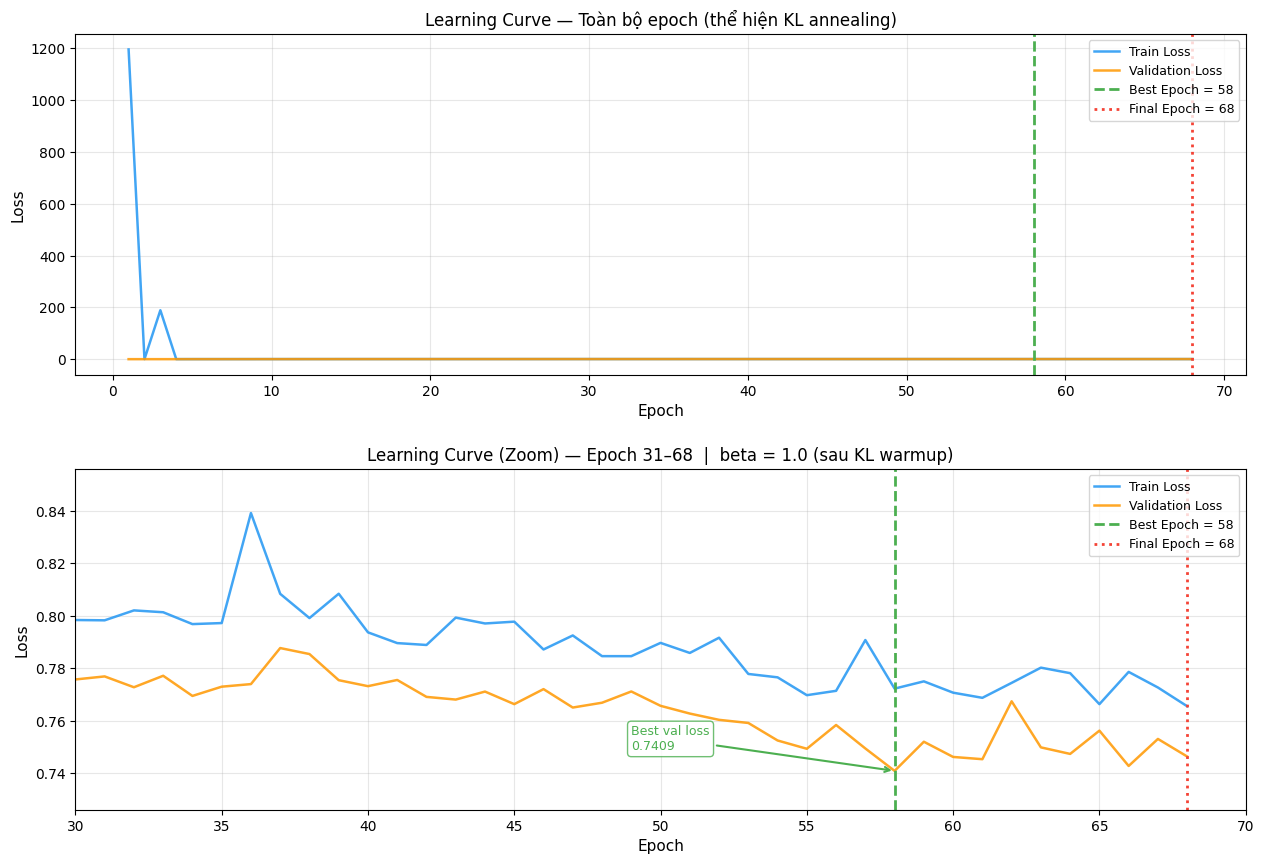

In [8]:
# ============================================================
# Vẽ Learning Curve với hai subplot:
#   (trên) Toàn bộ epoch — thể hiện KL annealing giai đoạn đầu
#   (dưới) Epoch >= 30  — phóng to vùng quan trọng khi beta = 1.0
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

epochs_x   = df.index.tolist()
train_vals = df["train_loss"].tolist()
val_vals   = df["val_loss"].tolist()

for ax_idx, ax in enumerate(axes):
    ax.plot(epochs_x, train_vals, label="Train Loss",
            color="#2196F3", linewidth=1.8, alpha=0.85)
    ax.plot(epochs_x, val_vals, label="Validation Loss",
            color="#FF9800", linewidth=1.8, alpha=0.85)

    # Đường dọc: best epoch (xanh lá)
    ax.axvline(x=best_epoch, color="#4CAF50", linestyle="--", linewidth=2.0,
               label=f"Best Epoch = {best_epoch}")
    # Đường dọc: final epoch (đỏ)
    if final_epoch != best_epoch:
        ax.axvline(x=final_epoch, color="#F44336", linestyle=":", linewidth=2.0,
                   label=f"Final Epoch = {final_epoch}")

    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Epoch", fontsize=11)
    ax.set_ylabel("Loss", fontsize=11)

# --- Subplot trên: toàn bộ epoch (hiển thị spike đầu do KL annealing) ---
axes[0].set_title("Learning Curve — Toàn bộ epoch (thể hiện KL annealing)", fontsize=12)
axes[0].legend(fontsize=9, loc="upper right")

# --- Subplot dưới: zoom vào giai đoạn beta = 1.0 (epoch 30 trở đi) ---
warmup_end = training_summary.get("kl_annealing", {}).get("beta_warmup_epochs", 30)
zoom_start = warmup_end + 1  # bắt đầu zoom sau KL warmup

df_zoom    = df.loc[zoom_start:]
z_train    = df_zoom["train_loss"].tolist()
z_val      = df_zoom["val_loss"].tolist()
z_epochs   = df_zoom.index.tolist()

# Annotate best val loss trên subplot dưới
axes[1].annotate(
    f"Best val loss\n{best_val_loss:.4f}",
    xy=(best_epoch, best_val_loss),
    xytext=(best_epoch - 9, best_val_loss + 0.008),
    arrowprops=dict(arrowstyle="->", color="#4CAF50", lw=1.5),
    fontsize=9, color="#4CAF50",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
              edgecolor="#4CAF50", alpha=0.8),
)

axes[1].set_xlim(zoom_start - 1, final_epoch + 2)
# Y-axis: phạm vi hợp lý cho giai đoạn beta=1.0
y_vals_zoom = z_train + z_val
axes[1].set_ylim(min(y_vals_zoom) * 0.98, max(y_vals_zoom) * 1.02)
axes[1].set_title(
    f"Learning Curve (Zoom) — Epoch {zoom_start}–{final_epoch}  |  beta = 1.0 (sau KL warmup)",
    fontsize=12
)
axes[1].legend(fontsize=9, loc="upper right")

plt.tight_layout(pad=2.0)

# --- Lưu hình ---
save_path = ARTIFACTS_OUT_DIR / "learning_curve_best_vs_final.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"[OK] Đã lưu hình: {save_path}")

plt.show()


## Section 8 — Phân Tích Early Stopping

In [10]:
# ============================================================
# Phân tích Early Stopping từ training_summary
# Tìm kiếm patience theo thứ tự ưu tiên:
#   1. hyperparameters.patience
#   2. root-level patience
#   3. early_stopping.patience (nếu là dict)
# ============================================================

def _find_patience(summary: dict, hp: dict):
    """Trả về giá trị patience từ nhiều vị trí có thể có."""
    # Ưu tiên 1: trong hyperparameters
    if hp.get("patience") is not None:
        return hp["patience"]
    # Ưu tiên 2: root-level
    if summary.get("patience") is not None:
        return summary["patience"]
    # Ưu tiên 3: key early_stopping là dict
    es = summary.get("early_stopping")
    if isinstance(es, dict) and es.get("patience") is not None:
        return es["patience"]
    return None

patience = _find_patience(training_summary, hyperparams)
stopped_early = results.get("stopped_early", None)

if patience is not None:
    # Số epoch không cải thiện sau best_epoch
    epochs_no_improve = final_epoch - best_epoch

    print("=" * 55)
    print("          PHÂN TÍCH EARLY STOPPING")
    print("=" * 55)
    print(f"  Patience              : {patience} epoch")
    print(f"  Best epoch            : {best_epoch}")
    print(f"  Final epoch           : {final_epoch}")
    print(f"  Stopped early         : {stopped_early}")
    print(f"  Số epoch không cải thiện sau best: {epochs_no_improve}")
    print("=" * 55)
    print()
    print(">>> Giải thích cơ chế Early Stopping:")
    print(f"    Sau epoch {best_epoch} (best epoch), validation loss không cải thiện")
    print(f"    trong {epochs_no_improve} epoch liên tiếp.")
    print(f"    Với patience = {patience}, training dừng lại ở epoch {final_epoch}")
    print(f"    để tránh mô hình tiếp tục overfit trên tập train.")
    print(f"    Checkpoint tại epoch {best_epoch} được lưu lại làm vae_best.pth.")

    # Kiểm tra xem epochs_no_improve có đúng bằng patience không
    if epochs_no_improve == patience:
        print(f"\n    [OK] Xác nhận: {final_epoch} - {best_epoch} = {epochs_no_improve} = patience({patience}) ✓")
    else:
        print(f"\n    [NOTE] {final_epoch} - {best_epoch} = {epochs_no_improve} ≠ patience({patience})")
        print(f"    Có thể training dừng vì đã đạt max_epochs hoặc điều kiện khác.")
else:
    print("Không tìm thấy thông tin early stopping trong training_summary.json.")
    print("Không thể xác định cơ chế dừng huấn luyện sớm.")


          PHÂN TÍCH EARLY STOPPING
  Patience              : 10 epoch
  Best epoch            : 58
  Final epoch           : 68
  Stopped early         : True
  Số epoch không cải thiện sau best: 10

>>> Giải thích cơ chế Early Stopping:
    Sau epoch 58 (best epoch), validation loss không cải thiện
    trong 10 epoch liên tiếp.
    Với patience = 10, training dừng lại ở epoch 68
    để tránh mô hình tiếp tục overfit trên tập train.
    Checkpoint tại epoch 58 được lưu lại làm vae_best.pth.

    [OK] Xác nhận: 68 - 58 = 10 = patience(10) ✓


## Section 9 — Kiểm Tra Checkpoint (state_dict)

`vae_best.pth` **không chỉ lưu một ma trận trọng số** — nó lưu toàn bộ `state_dict` của mô hình tại best epoch, bao gồm:

- Encoder weights & biases
- Mu layer (mean của phân phối latent)
- Logvar layer (log-variance của phân phối latent)
- Decoder weights & biases


In [11]:
# ============================================================
# Load checkpoint vae_best.pth và in danh sách state_dict keys
# ============================================================
if checkpoint_path.exists():
    # Load checkpoint về CPU để không phụ thuộc vào CUDA
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=True)

    # Checkpoint có thể là state_dict trực tiếp hoặc dict chứa "state_dict"
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
        print("[INFO] Checkpoint chứa key 'state_dict' — trích xuất nội bộ.")
    else:
        state_dict = checkpoint

    print(f"\n=== Checkpoint: {checkpoint_path.name} ===")
    print(f"Số lượng tensor trong state_dict: {len(state_dict)}\n")

    # --------------------------------------------------------
    # Phân loại từng key theo bộ phận mô hình
    # --------------------------------------------------------
    groups = {
        "Encoder"     : [],
        "Mu Layer"    : [],
        "Logvar Layer": [],
        "Decoder"     : [],
        "Khác"        : [],
    }

    for key, tensor in state_dict.items():
        shape = list(tensor.shape)
        numel = tensor.numel()
        if "encoder" in key.lower():
            groups["Encoder"].append((key, shape, numel))
        elif "fc_mu" in key.lower() or "mu" in key.lower():
            groups["Mu Layer"].append((key, shape, numel))
        elif "fc_logvar" in key.lower() or "logvar" in key.lower() or "log_var" in key.lower():
            groups["Logvar Layer"].append((key, shape, numel))
        elif "decoder" in key.lower():
            groups["Decoder"].append((key, shape, numel))
        else:
            groups["Khác"].append((key, shape, numel))

    total_params = 0
    for group_name, entries in groups.items():
        if not entries:
            continue
        print(f"--- {group_name} ---")
        for key, shape, numel in entries:
            print(f"  {key:40s} | shape={shape} | params={numel:,}")
            total_params += numel
        print()

    print(f"Tổng số tham số trong checkpoint: {total_params:,}")
    print(f"\n[OK] vae_best.pth lưu toàn bộ state_dict tại best epoch {best_epoch}.")
    print(     "     Đây là checkpoint dùng cho evaluate và inference.")
else:
    print(f"[SKIP] Không tìm thấy {checkpoint_path} — bỏ qua kiểm tra state_dict.")



=== Checkpoint: vae_best.pth ===
Số lượng tensor trong state_dict: 14

--- Encoder ---
  encoder.0.weight                         | shape=[128, 66] | params=8,448
  encoder.0.bias                           | shape=[128] | params=128
  encoder.2.weight                         | shape=[64, 128] | params=8,192
  encoder.2.bias                           | shape=[64] | params=64

--- Mu Layer ---
  fc_mu.weight                             | shape=[16, 64] | params=1,024
  fc_mu.bias                               | shape=[16] | params=16

--- Logvar Layer ---
  fc_logvar.weight                         | shape=[16, 64] | params=1,024
  fc_logvar.bias                           | shape=[16] | params=16

--- Decoder ---
  decoder.0.weight                         | shape=[64, 16] | params=1,024
  decoder.0.bias                           | shape=[64] | params=64
  decoder.2.weight                         | shape=[128, 64] | params=8,192
  decoder.2.bias                           | shape=[128] | p

## Section 10 — Kết Luận Học Thuật (Tự Động Sinh)

In [13]:
# ============================================================
# Sinh đoạn văn học thuật tự động dựa trên số liệu thực tế
# ============================================================

# Lấy thêm thông tin từ config và summary
latent_dim   = model_config.get("latent_dim", "N/A")
hidden_dims  = model_config.get("hidden_dims", [])
n_train      = results.get("n_train_samples", "N/A")
n_val        = results.get("n_val_samples",   "N/A")
total_time   = training_summary.get("total_time_seconds", None)
time_str     = f"{total_time:.1f} giây ({total_time/60:.1f} phút)" if total_time else "không rõ"

patience_str = str(patience) if patience else "không xác định"
delta_str    = f"{delta_val_loss:+.6f}"

conclusion_text = f"""
╔══════════════════════════════════════════════════════════════════╗
║      LÝ DO LỰA CHỌN CHECKPOINT TẠI BEST EPOCH                  ║
╚══════════════════════════════════════════════════════════════════╝

Trong quá trình huấn luyện mô hình Variational Autoencoder (VAE) cho
hệ thống phát hiện xâm nhập mạng (NIDS), mỗi epoch cập nhật toàn bộ
trọng số của mô hình thông qua thuật toán tối ưu hóa (Adam optimizer,
lr={hyperparams.get('learning_rate', 'N/A')}). Mô hình có kiến trúc với
input_dim={model_config.get('input_dim', 'N/A')}, hidden_dims={hidden_dims},
latent_dim={latent_dim}, và được huấn luyện trên {n_train:,} mẫu train,
đánh giá trên {n_val:,} mẫu validation.

Sau mỗi epoch, mô hình được đánh giá trên tập validation (tập dữ liệu
không tham gia vào quá trình cập nhật trọng số). Chỉ số validation loss
phản ánh khả năng tổng quát hóa (generalization) thực sự của mô hình —
tức là khả năng hoạt động tốt trên dữ liệu chưa thấy bao giờ.

Epoch tốt nhất (best epoch = {best_epoch}) là epoch có validation loss thấp
nhất trong toàn bộ quá trình huấn luyện (val_loss = {best_val_loss:.6f}).
Tại epoch này, mô hình đạt được sự cân bằng tốt nhất giữa:
  - Tái cấu trúc dữ liệu (reconstruction loss = {results.get('best_val_recon', 'N/A'):.6f})
  - Chính quy hóa không gian latent (KL divergence = {results.get('best_val_kl', 'N/A'):.6f})

Không lựa chọn epoch cuối (final epoch = {final_epoch}) vì tại epoch này,
val_loss = {final_val_loss:.6f}, cao hơn best epoch {delta_str}. Đây là dấu
hiệu cho thấy mô hình bắt đầu overfit trên tập train — train loss tiếp tục
giảm nhưng val loss không cải thiện thêm.

Cơ chế early stopping với patience = {patience_str} đã phát hiện điều này:
sau {final_epoch - best_epoch} epoch không cải thiện liên tiếp (từ epoch
{best_epoch+1} đến epoch {final_epoch}), quá trình huấn luyện được dừng lại.

Checkpoint tại best epoch được lưu tự động thành vae_best.pth, bao gồm
toàn bộ state_dict (encoder, mu layer, logvar layer, decoder). File này
được sử dụng cho cả evaluate (đánh giá threshold) và inference (dự đoán
trực tiếp trong backend FastAPI).

Tổng thời gian huấn luyện: {time_str}.
"""

print(conclusion_text)



╔══════════════════════════════════════════════════════════════════╗
║      LÝ DO LỰA CHỌN CHECKPOINT TẠI BEST EPOCH                  ║
╚══════════════════════════════════════════════════════════════════╝

Trong quá trình huấn luyện mô hình Variational Autoencoder (VAE) cho
hệ thống phát hiện xâm nhập mạng (NIDS), mỗi epoch cập nhật toàn bộ
trọng số của mô hình thông qua thuật toán tối ưu hóa (Adam optimizer,
lr=0.001). Mô hình có kiến trúc với
input_dim=66, hidden_dims=[128, 64],
latent_dim=16, và được huấn luyện trên 402,229 mẫu train,
đánh giá trên 100,558 mẫu validation.

Sau mỗi epoch, mô hình được đánh giá trên tập validation (tập dữ liệu
không tham gia vào quá trình cập nhật trọng số). Chỉ số validation loss
phản ánh khả năng tổng quát hóa (generalization) thực sự của mô hình —
tức là khả năng hoạt động tốt trên dữ liệu chưa thấy bao giờ.

Epoch tốt nhất (best epoch = 58) là epoch có validation loss thấp
nhất trong toàn bộ quá trình huấn luyện (val_loss = 0.740856).
Tại epoch n

## Section 11 — Xuất Tất Cả Artifact Ra File

In [14]:
# ============================================================
# 1. best_epoch_summary.csv — tóm tắt best epoch
# ============================================================
summary_csv_data = {
    "metric"  : ["best_epoch", "best_val_loss", "best_train_loss",
                 "final_epoch", "final_val_loss", "final_train_loss",
                 "delta_val_loss_final_minus_best",
                 "generalization_gap_best", "generalization_gap_final"],
    "value"   : [best_epoch, best_val_loss, best_train_loss,
                 final_epoch, final_val_loss, final_train_loss,
                 delta_val_loss,
                 best_gen_gap, final_gen_gap],
}
df_summary_csv = pd.DataFrame(summary_csv_data)
path_summary = ARTIFACTS_OUT_DIR / "best_epoch_summary.csv"
df_summary_csv.to_csv(path_summary, index=False)
print(f"[OK] {path_summary}")

# ============================================================
# 2. best_vs_final_epoch.csv — so sánh best vs final
# ============================================================
bvf_data = {
    "criterion"           : ["epoch", "train_loss", "val_loss",
                              "generalization_gap", "checkpoint_used"],
    "best_epoch"          : [best_epoch, best_train_loss, best_val_loss,
                              best_gen_gap, True],
    "final_epoch"         : [final_epoch, final_train_loss, final_val_loss,
                              final_gen_gap, False],
}
df_bvf = pd.DataFrame(bvf_data)
path_bvf = ARTIFACTS_OUT_DIR / "best_vs_final_epoch.csv"
df_bvf.to_csv(path_bvf, index=False)
print(f"[OK] {path_bvf}")

# ============================================================
# 3. neighbor_epoch_comparison.csv — so sánh epoch lân cận
# ============================================================
path_neighbor = ARTIFACTS_OUT_DIR / "neighbor_epoch_comparison.csv"
df_neighbor_export = df.loc[neighbor_start:neighbor_end].copy()
df_neighbor_export["is_best"] = df_neighbor_export.index == best_epoch
df_neighbor_export.to_csv(path_neighbor, index=True)
print(f"[OK] {path_neighbor}")

# ============================================================
# 4. best_epoch_report.txt — báo cáo dạng văn bản
# ============================================================
path_report = ARTIFACTS_OUT_DIR / "best_epoch_report.txt"
with open(path_report, "w", encoding="utf-8") as f:
    f.write(conclusion_text)
    f.write("\n\n")
    f.write("=== BẢNG TÓM TẮT BEST EPOCH ===\n")
    f.write(df_summary_csv.to_string(index=False))
    f.write("\n\n")
    f.write("=== BẢNG SO SÁNH BEST VS FINAL ===\n")
    f.write(df_bvf.to_string(index=False))
    f.write("\n\n")
    f.write(f"=== BẢNG EPOCH LÂN CẬN ({neighbor_start}–{neighbor_end}) ===\n")
    f.write(df_neighbor_export.to_string())
print(f"[OK] {path_report}")

# ============================================================
# 5. Xác nhận learning_curve_best_vs_final.png đã được lưu
# ============================================================
path_curve = ARTIFACTS_OUT_DIR / "learning_curve_best_vs_final.png"
if path_curve.exists():
    print(f"[OK] {path_curve}")
else:
    print(f"[WARNING] {path_curve} chưa được lưu — hãy chạy lại cell Section 7.")

# ============================================================
# In tổng kết và chỉ rõ file nào nên đưa vào báo cáo
# ============================================================
print("\n" + "=" * 60)
print("TÓM TẮT KẾT QUẢ")
print("=" * 60)
print(f"  Best epoch   : {best_epoch}")
print(f"  Best val loss: {best_val_loss:.6f}")
print(f"  Final epoch  : {final_epoch}")
print(f"  Lý do chọn   : Val loss tại epoch {best_epoch} ({best_val_loss:.6f})")
print(f"                 là THẤP NHẤT trong toàn bộ {final_epoch} epoch.")
print()
print("FILE NÊN ĐƯA VÀO BÁO CÁO:")
print("  [BÁO CÁO] learning_curve_best_vs_final.png")
print("            → Biểu đồ learning curve, minh họa trực quan best vs final epoch.")
print("  [PHỤ LỤC] neighbor_epoch_comparison.csv")
print("            → Bảng số liệu epoch lân cận, chứng minh best epoch có val_loss thấp nhất.")
print("  [PHỤ LỤC] best_vs_final_epoch.csv")
print("            → Bảng so sánh best epoch và final epoch.")
print("  [VĂN BẢN] best_epoch_report.txt")
print("            → Đoạn văn học thuật giải thích lý do chọn best epoch.")
print()
print("TẤT CẢ FILE ĐÃ LƯU TẠI:")
print(f"  {ARTIFACTS_OUT_DIR}")


[OK] D:\nids-vae-project\artifacts\experiments\best_epoch\best_epoch_summary.csv
[OK] D:\nids-vae-project\artifacts\experiments\best_epoch\best_vs_final_epoch.csv
[OK] D:\nids-vae-project\artifacts\experiments\best_epoch\neighbor_epoch_comparison.csv
[OK] D:\nids-vae-project\artifacts\experiments\best_epoch\best_epoch_report.txt
[OK] D:\nids-vae-project\artifacts\experiments\best_epoch\learning_curve_best_vs_final.png

TÓM TẮT KẾT QUẢ
  Best epoch   : 58
  Best val loss: 0.740856
  Final epoch  : 68
  Lý do chọn   : Val loss tại epoch 58 (0.740856)
                 là THẤP NHẤT trong toàn bộ 68 epoch.

FILE NÊN ĐƯA VÀO BÁO CÁO:
  [BÁO CÁO] learning_curve_best_vs_final.png
            → Biểu đồ learning curve, minh họa trực quan best vs final epoch.
  [PHỤ LỤC] neighbor_epoch_comparison.csv
            → Bảng số liệu epoch lân cận, chứng minh best epoch có val_loss thấp nhất.
  [PHỤ LỤC] best_vs_final_epoch.csv
            → Bảng so sánh best epoch và final epoch.
  [VĂN BẢN] best_epoch

---

## Phần Báo Cáo — Nội Dung Phục Vụ Chương 4 Đồ Án

> Các section từ **12 → 21** tạo ra **bảng đẹp** và **biểu đồ chuyên nghiệp** có thể chụp trực tiếp đưa vào báo cáo đồ án.
> Không chứa nội dung debug. Mọi giá trị được đọc động từ artifacts.

| Section | Nội dung | Phục vụ |
|---------|----------|---------|
| 12 | Bảng tổng quan checkpoint | Phần 1 |
| 13 | Bảng so sánh Best vs Final Epoch | Phần 2 |
| 14 | Bảng epoch lân cận ±5 | Phần 3 |
| 15 | Learning Curve chuyên nghiệp | Phần 4 |
| 16 | Biểu đồ Generalization Gap | Phần 5 |
| 17 | Biểu đồ Val Loss Zoom-In | Phần 6 |
| 18 | Bảng nội dung checkpoint (state_dict) | Phần 7 |
| 19 | Bảng vai trò các thành phần | Phần 8 |
| 20 | Nội dung báo cáo học thuật 4.x | Phần 9 |
| 21 | Tổng kết & kiểm tra file đã lưu | Phần 10 |

## Section 12 — Bảng Tổng Quan Checkpoint (Phần 1)

Bảng dưới tóm tắt toàn bộ thông tin của checkpoint được lựa chọn, cho phép giảng viên đánh giá nhanh quá trình chọn checkpoint.

**Highlight:** Best Epoch và Best Validation Loss.

In [27]:
import pandas as pd

# ============================================================
# Định nghĩa thư mục lưu biểu đồ dùng cho báo cáo
# Thư mục này dùng cho tất cả các section Phần Báo Cáo
# ============================================================
ANALYSIS_OUT_DIR = PROJECT_ROOT / "artifacts" / "analysis"
ANALYSIS_OUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Trích xuất thông tin cấu hình từ artifacts đã load
# ============================================================
_hp  = training_summary.get("hyperparameters", {})
_kl  = training_summary.get("kl_annealing", {})
_res = training_summary.get("results", {})

# Tính chênh lệch validation loss giữa final epoch và best epoch
_delta_vl = final_val_loss - best_val_loss

# ============================================================
# Xây dựng bảng tổng quan thông tin checkpoint
# Mỗi hàng là một thuộc tính quan trọng của checkpoint
# ============================================================
_overview_rows = [
    ("Best Epoch",                                str(_res.get("best_epoch", best_epoch))),
    ("Final Epoch (Epoch dừng training)",          str(_res.get("final_epoch", final_epoch))),
    ("Best Validation Loss",                       f"{_res.get('best_val_loss', best_val_loss):.6f}"),
    ("Final Validation Loss",                      f"{final_val_loss:.6f}"),
    ("Chênh lệch Validation Loss (Final − Best)",  f"{_delta_vl:+.6f}"),
    ("Warmup Epochs (KL Annealing)",               str(_kl.get("beta_warmup_epochs", 30))),
    ("Patience (Early Stopping)",                  str(_hp.get("patience", "N/A"))),
    ("Hidden Dims (Encoder / Decoder)",            str(_hp.get("hidden_dims", [128, 64]))),
    ("Latent Dim",                                 str(_hp.get("latent_dim", 16))),
    ("Tổng số tham số",                            f"{_res.get('n_params', 36834):,}"),
]

df_overview = pd.DataFrame(_overview_rows, columns=["Thuộc tính", "Giá trị"])

# ============================================================
# Highlight hai hàng quan trọng nhất: Best Epoch, Best Val Loss
# STYLE_BEST bao gồm color:#000000 — tránh chữ chìm trên dark theme
# ============================================================
_highlight_attrs = {"Best Epoch", "Best Validation Loss"}

def _style_overview(row):
    """Highlight hàng Best Epoch và Best Val Loss bằng STYLE_BEST."""
    if row["Thuộc tính"] in _highlight_attrs:
        return [STYLE_BEST] * 2
    return [""] * 2

# Mở rộng REPORT_TABLE_STYLES: căn trái cho bảng key-value
_overview_styles = REPORT_TABLE_STYLES + [
    {
        "selector": "th",
        "props": (
            "background-color: #343a40; color: #ffffff;"
            " font-weight: bold; padding: 8px 14px;"
            " text-align: left; border: 1px solid #495057;"
        ),
    },
    {
        "selector": "td",
        "props": (
            "padding: 8px 14px; border: 1px solid #495057;"
            " font-size: 13px; color: #f8f9fa; text-align: left;"
        ),
    },
]

styled_overview = (
    df_overview.style
    .apply(_style_overview, axis=1)
    .set_table_styles(_overview_styles)
    .set_caption("Bảng 4.x — Thông tin checkpoint được lựa chọn")
    .hide(axis="index")
)

display(styled_overview)


Thuộc tính,Giá trị
Best Epoch,58
Final Epoch (Epoch dừng training),68
Best Validation Loss,0.740856
Final Validation Loss,0.746338
Chênh lệch Validation Loss (Final − Best),+0.005482
Warmup Epochs (KL Annealing),30
Patience (Early Stopping),10
Hidden Dims (Encoder / Decoder),"[128, 64]"
Latent Dim,16
Tổng số tham số,"36,834"


## Section 13 — Bảng So Sánh Best Epoch vs Final Epoch (Phần 2)

Bảng so sánh chi tiết ba metric: **Train Loss**, **Validation Loss**, và **Generalization Gap** (= Val Loss − Train Loss) tại best epoch và final epoch.

> **Generalization Gap dương và tăng** từ best đến final epoch là bằng chứng rõ ràng của overfitting.

In [28]:
# ============================================================
# Tính Generalization Gap = Validation Loss - Train Loss
# Đây là thước đo mức độ overfitting của mô hình
# ============================================================
_best_gap  = best_val_loss  - best_train_loss   # gap tại best epoch
_final_gap = final_val_loss - final_train_loss  # gap tại final epoch

# Chênh lệch từ best → final
_d_train = final_train_loss - best_train_loss
_d_val   = final_val_loss   - best_val_loss
_d_gap   = _final_gap       - _best_gap

# ============================================================
# Sinh nhận xét tự động dựa trên hướng và độ lớn thay đổi
# ============================================================
def _remark_train(d: float) -> str:
    if d < -0.001:  return "Giảm → model tiếp tục học trên train"
    if d >  0.001:  return "Tăng → training không ổn định"
    return "Gần như không đổi"

def _remark_val(d: float) -> str:
    if d >  0.003:  return "Tăng ↑ — dấu hiệu overfitting"
    if d < -0.003:  return "Giảm ↓ — final tốt hơn (hiếm)"
    return "Ổn định — không cải thiện"

def _remark_gap(d: float) -> str:
    if d >  0.002:  return "Tăng ↑ — gap rộng hơn, overfit nặng hơn"
    if d < -0.002:  return "Giảm ↓ — ít overfit hơn"
    return "Gần như không đổi"

# ============================================================
# Xây dựng bảng so sánh đầy đủ 5 cột
# ============================================================
_comp_rows = [
    ("Train Loss",
     f"{best_train_loss:.6f}",  f"{final_train_loss:.6f}",
     f"{_d_train:+.6f}",        _remark_train(_d_train)),
    ("Validation Loss",
     f"{best_val_loss:.6f}",    f"{final_val_loss:.6f}",
     f"{_d_val:+.6f}",          _remark_val(_d_val)),
    ("Generalization Gap (Val − Train)",
     f"{_best_gap:+.6f}",       f"{_final_gap:+.6f}",
     f"{_d_gap:+.6f}",          _remark_gap(_d_gap)),
]

df_comp_report = pd.DataFrame(
    _comp_rows,
    columns=["Metric", f"Best Epoch ({best_epoch})", f"Final Epoch ({final_epoch})",
             "Chênh lệch (Final − Best)", "Nhận xét"]
)

# ============================================================
# Style: Validation Loss nổi bật (STYLE_WARNING), Gap màu xanh (STYLE_INFO)
# Cả hai đều có color:#000000 — tránh chữ trắng trên nền sáng
# ============================================================
def _style_comp_report(row):
    """Highlight Validation Loss = vàng, Generalization Gap = xanh dương nhạt."""
    if row["Metric"] == "Validation Loss":
        return [STYLE_WARNING] * 5
    if "Generalization" in row["Metric"]:
        return [STYLE_INFO] * 5
    return [""] * 5

styled_comp_report = (
    df_comp_report.style
    .apply(_style_comp_report, axis=1)
    .set_table_styles(REPORT_TABLE_STYLES)
    .set_caption(f"Bảng 4.x — So sánh Best Epoch ({best_epoch}) và Final Epoch ({final_epoch})")
    .hide(axis="index")
)

display(styled_comp_report)


Metric,Best Epoch (58),Final Epoch (68),Chênh lệch (Final − Best),Nhận xét
Train Loss,0.772250,0.765520,-0.006731,Giảm → model tiếp tục học trên train
Validation Loss,0.740856,0.746338,+0.005482,Tăng ↑ — dấu hiệu overfitting
Generalization Gap (Val − Train),-0.031394,-0.019182,+0.012212,"Tăng ↑ — gap rộng hơn, overfit nặng hơn"


## Section 14 — Bảng Epoch Lân Cận Best Epoch ±5 (Phần 3)

Bảng dưới hiển thị **Train Loss** và **Validation Loss** trong vùng **Best Epoch ± 5 epoch**, chứng minh best epoch là điểm có Validation Loss thấp nhất cục bộ.

> Hàng xanh = Best Epoch. Quan sát: Validation Loss tại best epoch thấp hơn tất cả các epoch xung quanh.

In [29]:
# ============================================================
# Xây dựng bảng epoch lân cận best_epoch ± 5
# Chứng minh best epoch là điểm có Validation Loss thấp nhất
# ============================================================
_NB_WIN   = 5
_nb_lo    = max(1, best_epoch - _NB_WIN)
_nb_hi    = min(final_epoch, best_epoch + _NB_WIN)

# Lấy dữ liệu từ DataFrame chính (df, epoch là index 1-based)
df_nb_report = df.loc[_nb_lo:_nb_hi, ["train_loss", "val_loss"]].copy()
df_nb_report.index.name = "Epoch"
df_nb_report = df_nb_report.rename(columns={
    "train_loss": "Train Loss",
    "val_loss":   "Validation Loss",
})

# Thêm cột đánh dấu best epoch để dễ nhận biết
df_nb_report[""] = df_nb_report.index.map(
    lambda e: "★ Best Epoch" if e == best_epoch else ""
)

# ============================================================
# Style: highlight toàn hàng best epoch bằng STYLE_BEST
# STYLE_BEST có color:#000000 — tránh chữ chìm trên dark theme
# ============================================================
def _style_nb_report(row):
    """Highlight dòng best epoch bằng nền xanh lá nhạt + chữ tối."""
    if row.name == best_epoch:
        return [STYLE_BEST] * len(row)
    return [""] * len(row)

styled_nb_report = (
    df_nb_report.style
    .apply(_style_nb_report, axis=1)
    .format({
        "Train Loss":      "{:.6f}",
        "Validation Loss": "{:.6f}",
    })
    .set_table_styles(REPORT_TABLE_STYLES)
    .set_caption(
        f"Bảng 4.x — Epoch lân cận Best Epoch ±{_NB_WIN} (Epoch {_nb_lo}–{_nb_hi})"
    )
)

display(styled_nb_report)


,Train Loss,Validation Loss,
Epoch,,,
53,0.777842,0.759143,
54,0.776552,0.752459,
55,0.769741,0.749295,
56,0.771405,0.758369,
57,0.790780,0.749407,
58,0.772250,0.740856,★ Best Epoch
59,0.775018,0.751979,
60,0.770698,0.746178,
61,0.768735,0.745317,


## Section 15 — Learning Curve Chuyên Nghiệp (Phần 4)

Biểu đồ hai panel:
- **Trái**: Toàn bộ quá trình huấn luyện (kể cả giai đoạn KL warmup)
- **Phải**: Giai đoạn beta = 1.0 (sau warmup) — phóng to để thấy rõ Best Epoch

Biểu đồ này được lưu vào `artifacts/analysis/learning_curve_best_epoch.png` để đưa vào báo cáo.

[OK] Đã lưu: D:\nids-vae-project\artifacts\analysis\learning_curve_best_epoch.png


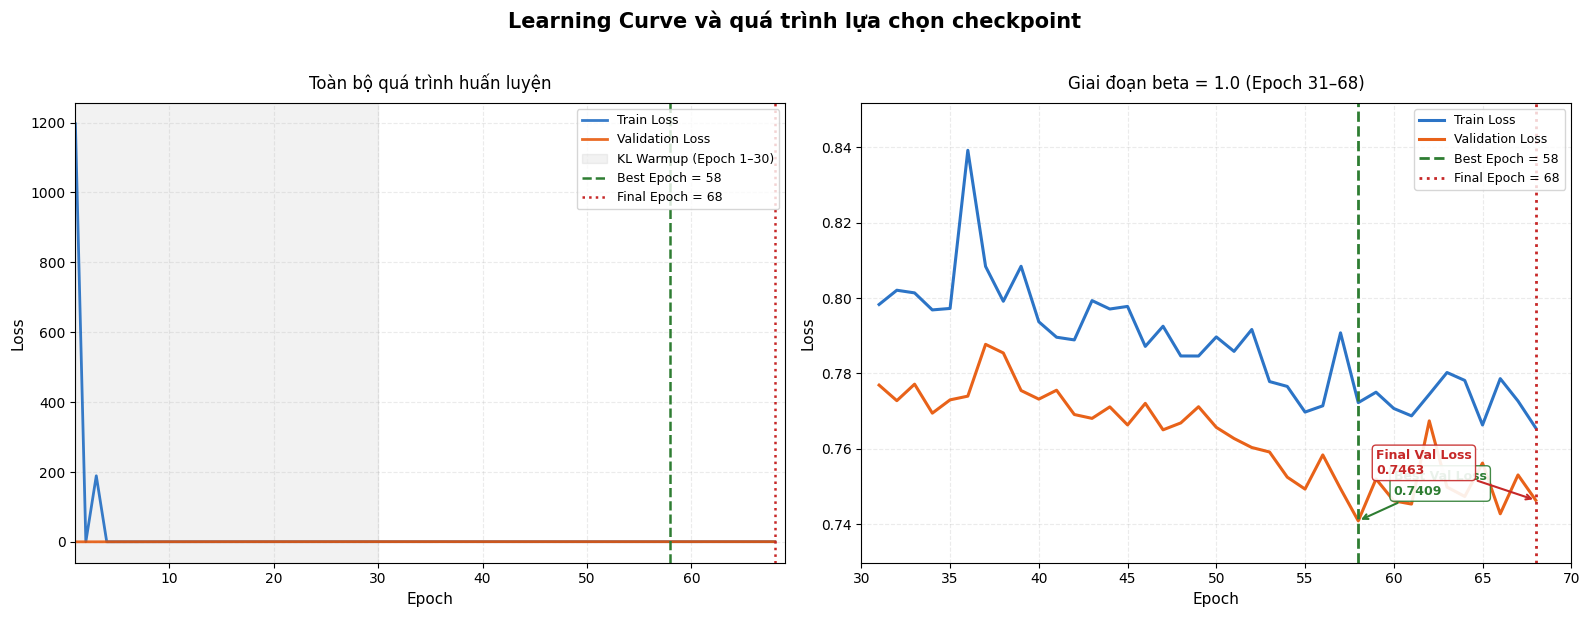

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ============================================================
# Chuẩn bị dữ liệu: toàn bộ epoch và vùng post-warmup
# ============================================================
_wu_epochs  = training_summary.get("kl_annealing", {}).get("beta_warmup_epochs", 30)
_pw_start   = _wu_epochs + 1  # epoch đầu tiên sau warmup

_ep_all     = df.index.tolist()
_tr_all     = df["train_loss"].tolist()
_va_all     = df["val_loss"].tolist()

# Dữ liệu vùng post-warmup (beta = 1.0) — để zoom subplot phải
_df_pw15    = df.loc[_pw_start:]
_ep_pw15    = _df_pw15.index.tolist()
_tr_pw15    = _df_pw15["train_loss"].tolist()
_va_pw15    = _df_pw15["val_loss"].tolist()

# ============================================================
# Vẽ biểu đồ hai panel
# ============================================================
fig15, (ax15_l, ax15_r) = plt.subplots(1, 2, figsize=(16, 6))
fig15.suptitle(
    "Learning Curve và quá trình lựa chọn checkpoint",
    fontsize=15, fontweight="bold", y=1.02
)

# ---- Màu sắc nhất quán ----
_COL_TRAIN  = "#1565C0"   # xanh dương đậm — Train Loss
_COL_VAL    = "#E65100"   # cam đậm          — Validation Loss
_COL_BEST   = "#2E7D32"   # xanh lá          — Best Epoch
_COL_FINAL  = "#C62828"   # đỏ               — Final Epoch

# ==================================================
# SUBPLOT TRÁI — Toàn bộ quá trình huấn luyện
# ==================================================
ax15_l.plot(_ep_all, _tr_all, color=_COL_TRAIN, lw=2.0, alpha=0.85, label="Train Loss")
ax15_l.plot(_ep_all, _va_all, color=_COL_VAL,   lw=2.0, alpha=0.85, label="Validation Loss")

# Vùng KL warmup (tô xám nhạt)
ax15_l.axvspan(1, _wu_epochs, alpha=0.10, color="gray", zorder=0,
               label=f"KL Warmup (Epoch 1–{_wu_epochs})")

# Đường dọc best epoch và final epoch
ax15_l.axvline(x=best_epoch,  color=_COL_BEST,  ls="--", lw=1.8,
               label=f"Best Epoch = {best_epoch}")
ax15_l.axvline(x=final_epoch, color=_COL_FINAL, ls=":",  lw=1.8,
               label=f"Final Epoch = {final_epoch}")

ax15_l.set_title("Toàn bộ quá trình huấn luyện", fontsize=12, pad=10)
ax15_l.set_xlabel("Epoch", fontsize=11)
ax15_l.set_ylabel("Loss", fontsize=11)
ax15_l.legend(fontsize=9, loc="upper right")
ax15_l.grid(True, alpha=0.25, linestyle="--")
ax15_l.set_xlim(1, final_epoch + 1)

# ==================================================
# SUBPLOT PHẢI — Zoom vùng post-warmup (beta = 1.0)
# ==================================================
ax15_r.plot(_ep_pw15, _tr_pw15, color=_COL_TRAIN, lw=2.2, alpha=0.9, label="Train Loss")
ax15_r.plot(_ep_pw15, _va_pw15, color=_COL_VAL,   lw=2.2, alpha=0.9, label="Validation Loss")

ax15_r.axvline(x=best_epoch,  color=_COL_BEST,  ls="--", lw=2.0,
               label=f"Best Epoch = {best_epoch}")
ax15_r.axvline(x=final_epoch, color=_COL_FINAL, ls=":",  lw=2.0,
               label=f"Final Epoch = {final_epoch}")

# Chú thích Best Validation Loss
ax15_r.annotate(
    f"Best Val Loss\n{best_val_loss:.4f}",
    xy=(best_epoch, best_val_loss),
    xytext=(best_epoch + 2, best_val_loss + 0.007),
    arrowprops=dict(arrowstyle="->", color=_COL_BEST, lw=1.5),
    fontsize=9, color=_COL_BEST, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=_COL_BEST, alpha=0.9),
)

# Chú thích Final Validation Loss
ax15_r.annotate(
    f"Final Val Loss\n{final_val_loss:.4f}",
    xy=(final_epoch, final_val_loss),
    xytext=(final_epoch - 9, final_val_loss + 0.007),
    arrowprops=dict(arrowstyle="->", color=_COL_FINAL, lw=1.5),
    fontsize=9, color=_COL_FINAL, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=_COL_FINAL, alpha=0.9),
)

ax15_r.set_title(f"Giai đoạn beta = 1.0 (Epoch {_pw_start}–{final_epoch})", fontsize=12, pad=10)
ax15_r.set_xlabel("Epoch", fontsize=11)
ax15_r.set_ylabel("Loss", fontsize=11)
ax15_r.legend(fontsize=9, loc="upper right")
ax15_r.grid(True, alpha=0.25, linestyle="--")
ax15_r.set_xlim(_pw_start - 1, final_epoch + 2)

# Y-axis: phạm vi hợp lý (loại bỏ khoảng trắng dư)
_y_pw_all = _tr_pw15 + _va_pw15
ax15_r.set_ylim(min(_y_pw_all) * 0.985, max(_y_pw_all) * 1.015)

plt.tight_layout()

# ============================================================
# Lưu biểu đồ vào artifacts/analysis/ để dùng trong báo cáo
# ============================================================
_path_lc = ANALYSIS_OUT_DIR / "learning_curve_best_epoch.png"
plt.savefig(_path_lc, dpi=150, bbox_inches="tight")
print(f"[OK] Đã lưu: {_path_lc}")
plt.show()


## Section 16 — Biểu Đồ Generalization Gap (Phần 5)

**Generalization Gap** = Validation Loss − Train Loss theo từng epoch.

- Gap dương và **tăng** sau best epoch → mô hình bắt đầu overfit
- Biểu đồ này minh họa rõ ràng tại sao không chọn epoch cuối

Lưu: `artifacts/analysis/generalization_gap.png`

[OK] Đã lưu: D:\nids-vae-project\artifacts\analysis\generalization_gap.png


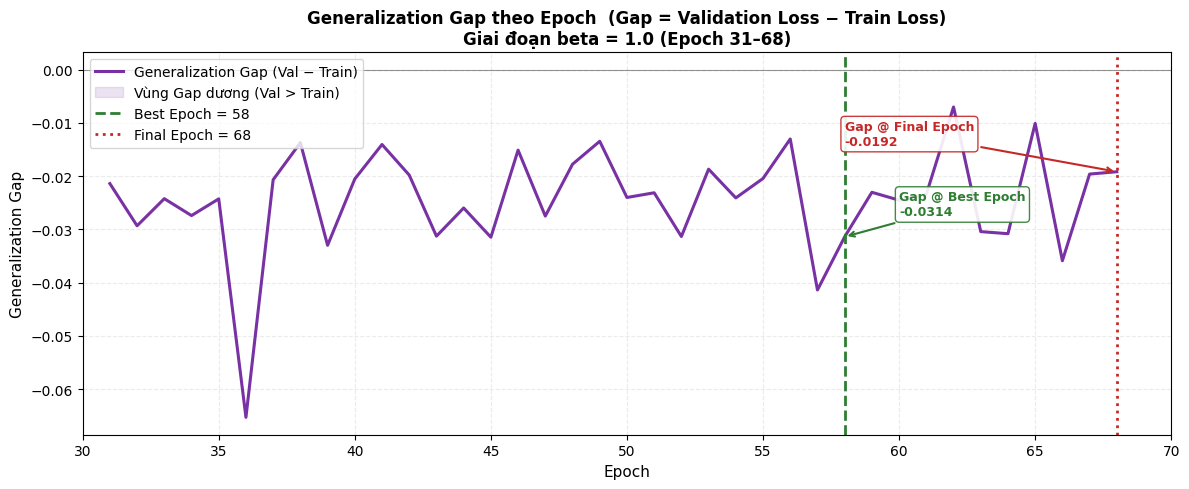

In [19]:
# ============================================================
# Tính Generalization Gap = Val Loss - Train Loss cho từng epoch
# Hiển thị vùng post-warmup để tránh spike do KL annealing
# ============================================================
_wu_pw16  = training_summary.get("kl_annealing", {}).get("beta_warmup_epochs", 30)
_pw16_start = _wu_pw16 + 1

# Chỉ lấy vùng post-warmup (beta = 1.0) để biểu đồ sạch và có ý nghĩa
_df_pw16  = df.loc[_pw16_start:]
_ep_pw16  = _df_pw16.index.tolist()
_gap_pw16 = (_df_pw16["val_loss"] - _df_pw16["train_loss"]).tolist()

# Giá trị gap tại best epoch và final epoch
_gap_at_best  = float(df.loc[best_epoch,  "val_loss"] - df.loc[best_epoch,  "train_loss"])
_gap_at_final = float(df.loc[final_epoch, "val_loss"] - df.loc[final_epoch, "train_loss"])

# ============================================================
# Vẽ biểu đồ Generalization Gap
# ============================================================
fig16, ax16 = plt.subplots(figsize=(12, 5))

_COL_GAP   = "#6A1B9A"   # tím — gap line
_COL_BEST  = "#2E7D32"   # xanh lá — best epoch
_COL_FINAL = "#C62828"   # đỏ       — final epoch

ax16.plot(_ep_pw16, _gap_pw16, color=_COL_GAP, lw=2.2, alpha=0.9,
          label="Generalization Gap (Val − Train)")

# Tô màu vùng gap dương (val > train → có khả năng overfit)
ax16.fill_between(_ep_pw16, _gap_pw16, 0,
                  where=[g > 0 for g in _gap_pw16],
                  alpha=0.12, color=_COL_GAP, label="Vùng Gap dương (Val > Train)")

ax16.axhline(y=0, color="black", lw=0.8, ls="-", alpha=0.4)

# Đường dọc best epoch và final epoch
ax16.axvline(x=best_epoch,  color=_COL_BEST,  ls="--", lw=2.0,
             label=f"Best Epoch = {best_epoch}")
ax16.axvline(x=final_epoch, color=_COL_FINAL, ls=":",  lw=2.0,
             label=f"Final Epoch = {final_epoch}")

# Chú thích gap tại best epoch
ax16.annotate(
    f"Gap @ Best Epoch\n{_gap_at_best:+.4f}",
    xy=(best_epoch, _gap_at_best),
    xytext=(best_epoch + 2, _gap_at_best + 0.004),
    arrowprops=dict(arrowstyle="->", color=_COL_BEST, lw=1.5),
    fontsize=9, color=_COL_BEST, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=_COL_BEST, alpha=0.9),
)

# Chú thích gap tại final epoch
ax16.annotate(
    f"Gap @ Final Epoch\n{_gap_at_final:+.4f}",
    xy=(final_epoch, _gap_at_final),
    xytext=(final_epoch - 10, _gap_at_final + 0.005),
    arrowprops=dict(arrowstyle="->", color=_COL_FINAL, lw=1.5),
    fontsize=9, color=_COL_FINAL, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=_COL_FINAL, alpha=0.9),
)

ax16.set_title(
    "Generalization Gap theo Epoch  (Gap = Validation Loss − Train Loss)\n"
    f"Giai đoạn beta = 1.0 (Epoch {_pw16_start}–{final_epoch})",
    fontsize=12, fontweight="bold"
)
ax16.set_xlabel("Epoch", fontsize=11)
ax16.set_ylabel("Generalization Gap", fontsize=11)
ax16.legend(fontsize=10, loc="upper left")
ax16.grid(True, alpha=0.25, linestyle="--")
ax16.set_xlim(_pw16_start - 1, final_epoch + 2)

plt.tight_layout()

# ============================================================
# Lưu biểu đồ vào artifacts/analysis/
# ============================================================
_path_gg = ANALYSIS_OUT_DIR / "generalization_gap.png"
plt.savefig(_path_gg, dpi=150, bbox_inches="tight")
print(f"[OK] Đã lưu: {_path_gg}")
plt.show()


## Section 17 — Biểu Đồ Val Loss Zoom-In (Phần 6)

Biểu đồ phóng to Validation Loss trong **vùng Best Epoch ± 8 epoch**, với marker tại từng epoch.

Mục đích: Chứng minh trực quan rằng **Epoch 58 có Validation Loss thấp hơn Epoch 57, 59, 60, ...**

Lưu: `artifacts/analysis/val_loss_zoom_best_epoch.png`

[OK] Đã lưu: D:\nids-vae-project\artifacts\analysis\val_loss_zoom_best_epoch.png


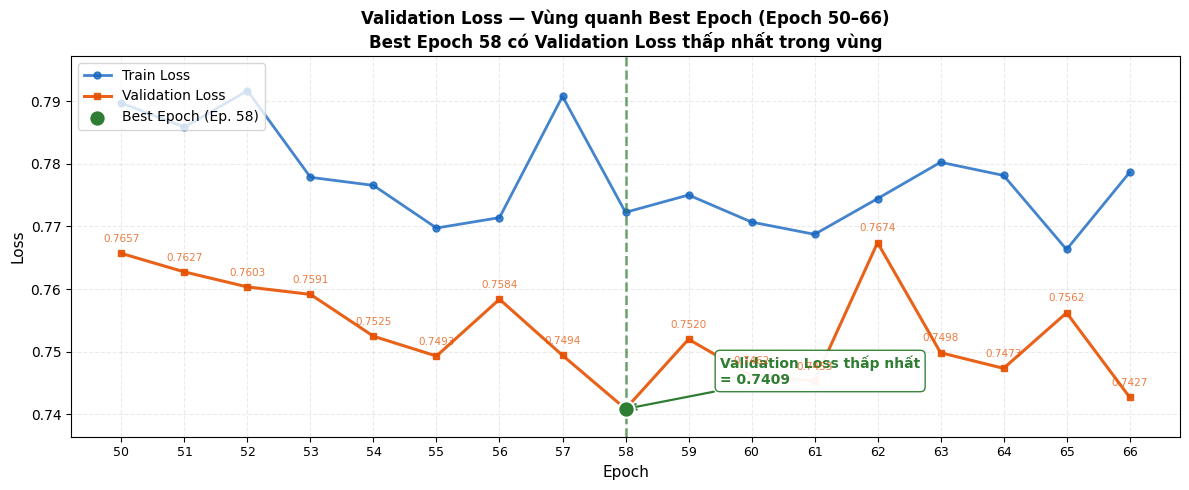

In [20]:
# ============================================================
# Lấy dữ liệu vùng zoom quanh best epoch (±8 epoch)
# Phạm vi này đủ rộng để thấy xu hướng cục bộ của val loss
# ============================================================
_ZM_MARGIN = 8
_zm_lo     = max(1, best_epoch - _ZM_MARGIN)
_zm_hi     = min(final_epoch, best_epoch + _ZM_MARGIN)

_df_zoom17 = df.loc[_zm_lo:_zm_hi]
_ep_zm     = _df_zoom17.index.tolist()
_tr_zm     = _df_zoom17["train_loss"].tolist()
_va_zm     = _df_zoom17["val_loss"].tolist()

# ============================================================
# Vẽ biểu đồ zoom-in Validation Loss
# ============================================================
fig17, ax17 = plt.subplots(figsize=(12, 5))

_COL_TRAIN = "#1565C0"
_COL_VAL   = "#E65100"
_COL_BEST  = "#2E7D32"

# Vẽ đường Train Loss và Validation Loss với marker
ax17.plot(_ep_zm, _tr_zm, color=_COL_TRAIN, lw=2.0, marker="o",
          markersize=5, alpha=0.8, label="Train Loss")
ax17.plot(_ep_zm, _va_zm, color=_COL_VAL,   lw=2.2, marker="s",
          markersize=5, alpha=0.9, label="Validation Loss")

# Điểm nổi bật: best epoch trên đường Validation Loss
ax17.scatter([best_epoch], [best_val_loss],
             color=_COL_BEST, s=140, zorder=6,
             label=f"Best Epoch (Ep. {best_epoch})", edgecolors="white", linewidths=1.5)

# Đường dọc best epoch
ax17.axvline(x=best_epoch, color=_COL_BEST, ls="--", lw=1.8, alpha=0.7)

# Chú thích giá trị Validation Loss thấp nhất
ax17.annotate(
    f"Validation Loss thấp nhất\n= {best_val_loss:.4f}",
    xy=(best_epoch, best_val_loss),
    xytext=(best_epoch + 1.5, best_val_loss + 0.004),
    arrowprops=dict(arrowstyle="->", color=_COL_BEST, lw=1.6),
    fontsize=10, fontweight="bold", color=_COL_BEST,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
              edgecolor=_COL_BEST, alpha=0.95),
)

# Hiển thị giá trị Validation Loss trên mỗi điểm
for _e, _v in zip(_ep_zm, _va_zm):
    if _e == best_epoch:
        continue  # đã có annotation riêng
    ax17.text(_e, _v + 0.0015, f"{_v:.4f}",
              ha="center", va="bottom", fontsize=7.5, color=_COL_VAL, alpha=0.75)

# X-axis: tick mỗi epoch
ax17.set_xticks(_ep_zm)
ax17.set_xticklabels([str(e) for e in _ep_zm], fontsize=9)

ax17.set_title(
    f"Validation Loss — Vùng quanh Best Epoch (Epoch {_zm_lo}–{_zm_hi})\n"
    f"Best Epoch {best_epoch} có Validation Loss thấp nhất trong vùng",
    fontsize=12, fontweight="bold"
)
ax17.set_xlabel("Epoch", fontsize=11)
ax17.set_ylabel("Loss", fontsize=11)
ax17.legend(fontsize=10, loc="upper left")
ax17.grid(True, alpha=0.25, linestyle="--")

# Y-axis: phạm vi sát với dữ liệu
_y_zm = _tr_zm + _va_zm
ax17.set_ylim(min(_y_zm) * 0.994, max(_y_zm) * 1.007)

plt.tight_layout()

# ============================================================
# Lưu biểu đồ vào artifacts/analysis/
# ============================================================
_path_zm = ANALYSIS_OUT_DIR / "val_loss_zoom_best_epoch.png"
plt.savefig(_path_zm, dpi=150, bbox_inches="tight")
print(f"[OK] Đã lưu: {_path_zm}")
plt.show()


## Section 18 — Bảng Nội Dung Checkpoint vae_best.pth (Phần 7)

`vae_best.pth` lưu toàn bộ `state_dict` của mô hình tại best epoch.
Bảng dưới liệt kê **từng layer**, **shape của weight tensor**, và **số tham số** (weight + bias).

In [30]:
import re

# ============================================================
# Bản đồ tên layer từ key prefix trong state_dict → tên đẹp
# Thứ tự trong list quyết định thứ tự ưu tiên match
# ============================================================
_LAYER_NAME_MAP = [
    (r"encoder\.0",   "Encoder Layer 1"),
    (r"encoder\.2",   "Encoder Layer 2"),
    (r"encoder\.4",   "Encoder Layer 3"),
    (r"fc_mu",        "Mu Layer (μ)"),
    (r"fc_logvar",    "LogVar Layer (log σ²)"),
    (r"mu",           "Mu Layer (μ)"),
    (r"logvar",       "LogVar Layer (log σ²)"),
    (r"decoder\.0",   "Decoder Layer 1"),
    (r"decoder\.2",   "Decoder Layer 2"),
    (r"decoder\.4",   "Decoder Layer 3"),
    (r"decoder\.6",   "Output Layer"),
    (r"output",       "Output Layer"),
]

def _friendly_layer(key_prefix: str) -> str:
    """Tra cứu tên đẹp từ key prefix của tensor."""
    for _pat, _name in _LAYER_NAME_MAP:
        if re.fullmatch(_pat, key_prefix):
            return _name
    return key_prefix  # fallback: giữ nguyên tên gốc

# ============================================================
# Nhóm các tensor theo layer (gộp weight + bias thành 1 hàng)
# ============================================================
_layers_ordered = {}  # OrderedDict: key_prefix → {"weight": tensor, "bias": tensor}
for _k, _t in state_dict.items():
    _parts = _k.rsplit(".", 1)
    if len(_parts) == 2 and _parts[1] in ("weight", "bias"):
        _base = _parts[0]
        if _base not in _layers_ordered:
            _layers_ordered[_base] = {}
        _layers_ordered[_base][_parts[1]] = _t
    else:
        # Tensor không có suffix .weight/.bias (hiếm gặp)
        if _k not in _layers_ordered:
            _layers_ordered[_k] = {}
        _layers_ordered[_k]["weight"] = _t

# ============================================================
# Xây dựng các hàng bảng: tên layer, weight shape, tổng params
# ============================================================
_ckpt18_rows = []
_grand_params = 0

for _base, _tensors in _layers_ordered.items():
    _w = _tensors.get("weight")
    _b = _tensors.get("bias")

    # Shape: lấy từ weight tensor (thể hiện chiều vào × chiều ra)
    if _w is not None:
        _sh = list(_w.shape)
        _shape_str = " × ".join(str(d) for d in _sh)
    else:
        _shape_str = "—"

    # Tổng số tham số của layer (weight + bias)
    _lp = sum(t.numel() for t in [_w, _b] if t is not None)
    _grand_params += _lp

    _ckpt18_rows.append((_friendly_layer(_base), _shape_str, f"{_lp:,}"))

# Thêm dòng tổng kết
_total_tensors18 = len(state_dict)
_ckpt18_rows.append(("Tổng số tensor", "—", f"{_total_tensors18}"))
_ckpt18_rows.append(("Tổng số tham số", "—", f"{_grand_params:,}"))

df_ckpt18 = pd.DataFrame(
    _ckpt18_rows,
    columns=["Thành phần", "Weight Shape", "Số tham số"]
)

# ============================================================
# Style: Mu/LogVar (STYLE_INFO + in nghiêng), dòng tổng kết (đen tối)
# Tất cả nền sáng đều kèm color:#000000 — tránh chữ chìm dark theme
# ============================================================
def _style_ckpt18(row):
    """Highlight Mu/LogVar (latent space) và dòng tổng kết."""
    if row["Thành phần"] in ("Tổng số tensor", "Tổng số tham số"):
        # Nền tối + chữ sáng — luôn đọc được trên mọi theme
        return ["background-color:#343a40; color:#ffffff; font-weight:bold;"] * 3
    if row["Thành phần"] in ("Mu Layer (μ)", "LogVar Layer (log σ²)"):
        # Nền xanh nhạt + chữ tối + in nghiêng
        return ["background-color:#cff4fc; color:#000000; font-style:italic;"] * 3
    return [""] * 3

styled_ckpt18 = (
    df_ckpt18.style
    .apply(_style_ckpt18, axis=1)
    .set_table_styles(REPORT_TABLE_STYLES)
    .set_caption(
        f"Bảng 4.x — Nội dung checkpoint vae_best.pth "
        f"({_total_tensors18} tensor, {_grand_params:,} tham số)"
    )
    .hide(axis="index")
)

display(styled_ckpt18)


Thành phần,Weight Shape,Số tham số
Encoder Layer 1,128 × 66,"8,576"
Encoder Layer 2,64 × 128,"8,256"
Mu Layer (μ),16 × 64,"1,040"
LogVar Layer (log σ²),16 × 64,"1,040"
Decoder Layer 1,64 × 16,"1,088"
Decoder Layer 2,128 × 64,"8,320"
Decoder Layer 3,66 × 128,"8,514"
Tổng số tensor,—,14
Tổng số tham số,—,"36,834"


## Section 19 — Bảng Giải Thích Thành Phần Checkpoint (Phần 8)

Bảng giải thích **vai trò của từng thành phần** trong checkpoint VAE, phục vụ phần bảo vệ đồ án.

> **Latent Space** là khái niệm cốt lõi: dữ liệu bình thường → z gần trung tâm → reconstruction error nhỏ. Dữ liệu bất thường → z lệch xa → reconstruction error lớn → cảnh báo xâm nhập.

In [31]:
# ============================================================
# Xây dựng bảng giải thích vai trò từng thành phần trong VAE
# Dùng cho slide bảo vệ và phần phương pháp trong báo cáo
# ============================================================
_hp19   = training_summary.get("hyperparameters", {})
_in_dim = model_config.get("input_dim", 66)
_hd     = model_config.get("hidden_dims", [128, 64])
_ld     = model_config.get("latent_dim", 16)

_explain19_rows = [
    ("Encoder",
     f"Mạng nơ-ron nén dữ liệu đầu vào ({_in_dim} đặc trưng) "
     f"xuống hidden dims {_hd}. Học biểu diễn đặc trưng từ lưu lượng mạng bình thường."),
    ("Mu Layer (μ)",
     f"Lớp tuyến tính ({_hd[-1]}→{_ld}) ánh xạ sang vector trung bình "
     "của phân phối Gaussian trong không gian latent. "
     "Đại diện cho vị trí trung tâm của mẫu trong không gian latent."),
    ("LogVar Layer (log σ²)",
     f"Lớp tuyến tính ({_hd[-1]}→{_ld}) ánh xạ sang log-variance. "
     "Điều khiển mức độ không chắc chắn (uncertainty) trong không gian latent. "
     "Cùng với Mu, xác định toàn bộ phân phối xác suất q(z|x)."),
    ("Latent Space (z)",
     f"Không gian tiềm ẩn {_ld} chiều. Vector z được lấy mẫu từ N(μ, σ²) "
     "qua reparameterization trick (z = μ + σ·ε). "
     "Dữ liệu BENIGN → z gần gốc tọa độ. Dữ liệu attack → z lệch xa."),
    ("Decoder",
     f"Mạng nơ-ron tái cấu trúc từ không gian latent ({_ld} chiều) "
     f"về hidden dims {list(reversed(_hd))}. "
     "Học cách xây dựng lại dữ liệu bình thường với sai số nhỏ nhất."),
    ("Output Layer",
     f"Lớp đầu ra tuyến tính (→{_in_dim}) tái cấu trúc toàn bộ vector đặc trưng. "
     "Reconstruction error = MSE(x̂, x). "
     "Ngưỡng phát hiện: reconstruction error > threshold → cảnh báo xâm nhập."),
]

df_explain19 = pd.DataFrame(
    _explain19_rows,
    columns=["Thành phần", "Vai trò trong VAE NIDS"]
)

# ============================================================
# Style: Latent Space (STYLE_WARNING), Mu/LogVar (STYLE_INFO),
# Output Layer (hồng nhạt) — tất cả đều có color:#000000
# ============================================================
def _style_explain19(row):
    """Highlight từng thành phần theo vai trò — dark/light theme safe."""
    if row["Thành phần"] == "Latent Space (z)":
        return [STYLE_WARNING] * 2
    if row["Thành phần"] in ("Mu Layer (μ)", "LogVar Layer (log σ²)"):
        return [STYLE_INFO] * 2
    if row["Thành phần"] == "Output Layer":
        # Hồng nhạt + chữ tối — không nằm trong STYLE constants nên inline
        return ["background-color:#f8d7da; color:#000000;"] * 2
    return [""] * 2

# Mở rộng REPORT_TABLE_STYLES: căn trái + line-height cho bảng mô tả dài
_explain19_styles = REPORT_TABLE_STYLES + [
    {
        "selector": "th",
        "props": (
            "background-color: #343a40; color: #ffffff;"
            " font-weight: bold; padding: 8px 14px;"
            " text-align: left; border: 1px solid #495057;"
        ),
    },
    {
        "selector": "td",
        "props": (
            "padding: 8px 14px; border: 1px solid #495057;"
            " font-size: 13px; color: #f8f9fa;"
            " text-align: left; line-height: 1.55;"
        ),
    },
    {
        "selector": "td:first-child",
        "props": (
            "font-weight: bold; white-space: nowrap;"
            " min-width: 160px; padding: 8px 14px;"
        ),
    },
]

styled_explain19 = (
    df_explain19.style
    .apply(_style_explain19, axis=1)
    .set_table_styles(_explain19_styles)
    .set_caption("Bảng 4.x — Vai trò từng thành phần trong checkpoint VAE")
    .hide(axis="index")
)

display(styled_explain19)


Thành phần,Vai trò trong VAE NIDS
Encoder,"Mạng nơ-ron nén dữ liệu đầu vào (66 đặc trưng) xuống hidden dims [128, 64]. Học biểu diễn đặc trưng từ lưu lượng mạng bình thường."
Mu Layer (μ),Lớp tuyến tính (64→16) ánh xạ sang vector trung bình của phân phối Gaussian trong không gian latent. Đại diện cho vị trí trung tâm của mẫu trong không gian latent.
LogVar Layer (log σ²),"Lớp tuyến tính (64→16) ánh xạ sang log-variance. Điều khiển mức độ không chắc chắn (uncertainty) trong không gian latent. Cùng với Mu, xác định toàn bộ phân phối xác suất q(z|x)."
Latent Space (z),"Không gian tiềm ẩn 16 chiều. Vector z được lấy mẫu từ N(μ, σ²) qua reparameterization trick (z = μ + σ·ε). Dữ liệu BENIGN → z gần gốc tọa độ. Dữ liệu attack → z lệch xa."
Decoder,"Mạng nơ-ron tái cấu trúc từ không gian latent (16 chiều) về hidden dims [64, 128]. Học cách xây dựng lại dữ liệu bình thường với sai số nhỏ nhất."
Output Layer,"Lớp đầu ra tuyến tính (→66) tái cấu trúc toàn bộ vector đặc trưng. Reconstruction error = MSE(x̂, x). Ngưỡng phát hiện: reconstruction error > threshold → cảnh báo xâm nhập."


## Section 20 — Nội Dung Báo Cáo Học Thuật 4.x (Phần 9)

Đoạn văn học thuật hoàn chỉnh cho **Chương 4 — Thực nghiệm và Đánh giá**.

> **Copy trực tiếp vào Word/LaTeX.** Thay thế các placeholder bằng hình ảnh/bảng tương ứng.
> Mọi giá trị số được sinh tự động từ artifacts — không hardcode.

In [23]:
# ============================================================
# Sinh nội dung học thuật cho Chương 4 báo cáo đồ án
# Tất cả giá trị số được lấy trực tiếp từ artifacts
# ============================================================
_hp20   = training_summary.get("hyperparameters", {})
_kl20   = training_summary.get("kl_annealing", {})
_res20  = training_summary.get("results", {})

_in_dim20   = model_config.get("input_dim", 66)
_hd20       = model_config.get("hidden_dims", [128, 64])
_ld20       = model_config.get("latent_dim", 16)
_n_params20 = _res20.get("n_params", 36834)
_lr20       = _hp20.get("learning_rate", 0.001)
_wd20       = _hp20.get("weight_decay", 1e-5)
_max_ep20   = _hp20.get("max_epochs", 100)
_pat20      = _hp20.get("patience", 10)
_wu20       = _kl20.get("beta_warmup_epochs", 30)
_n_tr20     = _res20.get("n_train_samples", 402229)
_n_va20     = _res20.get("n_val_samples", 100558)
_bep20      = _res20.get("best_epoch", best_epoch)
_fep20      = _res20.get("final_epoch", final_epoch)
_bvl20      = _res20.get("best_val_loss", best_val_loss)
_bvr20      = _res20.get("best_val_recon", 0.6354)
_bvk20      = _res20.get("best_val_kl", 0.1054)

_gap_best20  = best_val_loss  - best_train_loss
_gap_final20 = final_val_loss - final_train_loss

# ============================================================
# Soạn thảo nội dung học thuật đầy đủ với placeholder hình ảnh
# ============================================================
_report20 = f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4.x. Lựa chọn checkpoint tối ưu trong quá trình huấn luyện
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

4.x.1. Mục tiêu
───────────────
Trong huấn luyện mạng nơ-ron sâu, số epoch tốt nhất (best epoch) không
nhất thiết là epoch cuối cùng của quá trình tối ưu hóa. Phần này trình
bày cơ sở lý luận và bằng chứng thực nghiệm về việc lựa chọn checkpoint
tại epoch {_bep20} cho mô hình Variational Autoencoder (VAE) trong hệ
thống phát hiện xâm nhập mạng (NIDS) dựa trên tập dữ liệu CICIDS2017.

4.x.2. Thiết lập thực nghiệm
─────────────────────────────
Mô hình VAE được huấn luyện với cấu hình:
  - Kiến trúc     : input_dim={_in_dim20}, hidden_dims={_hd20}, latent_dim={_ld20}
                    ({_n_params20:,} tham số có thể học)
  - Tập huấn luyện: {_n_tr20:,} luồng mạng bình thường (BENIGN — CICIDS2017)
  - Tập validation: {_n_va20:,} luồng mạng (không tham gia cập nhật trọng số)
  - Optimizer     : Adam (lr={_lr20}, weight_decay={_wd20})
  - Max epochs    : {_max_ep20}
  - KL Annealing  : beta tăng tuyến tính 0.0 → 1.0 trong {_wu20} epoch đầu
  - Early stopping: patience = {_pat20} (chỉ kích hoạt sau khi KL warmup kết thúc)

[CHÈN BẢNG BEST EPOCH]

4.x.3. Kết quả
──────────────
Sau khi KL warmup hoàn tất (epoch {_wu20}), mô hình được đánh giá trên
tập validation sau mỗi epoch. Validation loss thấp nhất đạt được tại
epoch {_bep20}:

  - Best Validation Loss    : {_bvl20:.6f}
    (Reconstruction Loss = {_bvr20:.6f}, KL Divergence = {_bvk20:.6f})
  - Train Loss @ Best Epoch : {best_train_loss:.6f}
  - Generalization Gap      : {_gap_best20:+.6f}  (Validation − Train)
  - Final Epoch             : {_fep20}  (training dừng do early stopping)
  - Final Validation Loss   : {final_val_loss:.6f}  (tăng {final_val_loss - best_val_loss:+.6f} so với best)
  - Generalization Gap @ Final: {_gap_final20:+.6f}  (tăng {_gap_final20 - _gap_best20:+.6f})

[CHÈN HÌNH LEARNING CURVE]

4.x.4. Phân tích
────────────────
Sau epoch {_bep20}, mô hình tiếp tục được huấn luyện nhưng Validation Loss
không giảm thêm. Đây là dấu hiệu điển hình của overfitting:

  (a) Train Loss tiếp tục giảm ({best_train_loss:.6f} → {final_train_loss:.6f}),
      cho thấy mô hình vẫn đang học trên tập train.
  (b) Validation Loss tăng ({best_val_loss:.6f} → {final_val_loss:.6f}),
      cho thấy khả năng tổng quát hóa đang suy giảm.
  (c) Generalization Gap tăng ({_gap_best20:+.6f} → {_gap_final20:+.6f}),
      xác nhận xu hướng overfit ngày càng rõ ràng hơn.

Cơ chế early stopping phát hiện điều này: sau {_fep20 - _bep20} epoch liên
tiếp ({_bep20+1}–{_fep20}) không cải thiện Validation Loss (bằng đúng
patience = {_pat20}), quá trình huấn luyện dừng lại.

[CHÈN HÌNH GENERALIZATION GAP]

4.x.5. Kết luận
───────────────
Checkpoint tại epoch {_bep20} (vae_best.pth) được lựa chọn vì:

  (1) Validation Loss thấp nhất ({_bvl20:.6f}) trong toàn bộ {_fep20} epoch
      → khả năng tổng quát hóa tốt nhất trên dữ liệu chưa thấy.
  (2) Generalization Gap nhỏ nhất tại best epoch → mức độ overfitting thấp nhất.
  (3) Early stopping xác nhận đây là điểm tối ưu: {_fep20 - _bep20} epoch
      sau best epoch không cải thiện, đúng bằng patience = {_pat20}.

Checkpoint này bao gồm toàn bộ state_dict của mô hình (encoder, mu layer,
logvar layer, decoder — {_n_params20:,} tham số) và được sử dụng nhất quán
cho cả đánh giá ngưỡng (threshold calibration) lẫn suy luận thực tế
(FastAPI inference), đảm bảo không có sự phân kỳ giữa huấn luyện và triển khai.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

print(_report20)

# ============================================================
# Lưu nội dung báo cáo ra file text để copy vào Word/LaTeX
# ============================================================
_rpt20_path = ANALYSIS_OUT_DIR / "section_4x_checkpoint_selection.txt"
with open(_rpt20_path, "w", encoding="utf-8") as _f20:
    _f20.write(_report20.strip())
print(f"\n[OK] Đã lưu: {_rpt20_path}")
print("     → Copy nội dung trên trực tiếp vào Word/LaTeX báo cáo đồ án.")
print("     → Thay thế [CHÈN ...] bằng hình ảnh/bảng tương ứng.")



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4.x. Lựa chọn checkpoint tối ưu trong quá trình huấn luyện
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

4.x.1. Mục tiêu
───────────────
Trong huấn luyện mạng nơ-ron sâu, số epoch tốt nhất (best epoch) không
nhất thiết là epoch cuối cùng của quá trình tối ưu hóa. Phần này trình
bày cơ sở lý luận và bằng chứng thực nghiệm về việc lựa chọn checkpoint
tại epoch 58 cho mô hình Variational Autoencoder (VAE) trong hệ
thống phát hiện xâm nhập mạng (NIDS) dựa trên tập dữ liệu CICIDS2017.

4.x.2. Thiết lập thực nghiệm
─────────────────────────────
Mô hình VAE được huấn luyện với cấu hình:
  - Kiến trúc     : input_dim=66, hidden_dims=[128, 64], latent_dim=16
                    (36,834 tham số có thể học)
  - Tập huấn luyện: 402,229 luồng mạng bình thường (BENIGN — CICIDS2017)
  - Tập validation: 100,558 luồng mạng (không tham gia cập nhật trọng số)
  - Optimizer     : Adam (lr=0.001, weight_decay=1e-05)
  - Max epochs 

## Section 21 — Tổng Kết (Phần 10)

Liệt kê tất cả bảng mới, biểu đồ mới, và nội dung báo cáo đã sinh trong notebook này.
Kiểm tra file đã lưu thành công vào `artifacts/analysis/`.

In [24]:
# ============================================================
# Tổng kết toàn bộ nội dung mới được tạo trong phần báo cáo
# ============================================================

# Danh sách bảng mới (tên bảng, section, mô tả ngắn)
_new_tables = [
    ("Bảng tổng quan checkpoint",              "Section 12",
     "10 thuộc tính, highlight Best Epoch & Best Val Loss"),
    ("Bảng so sánh Best Epoch vs Final Epoch", "Section 13",
     "3 metric + Chênh lệch + Nhận xét tự động"),
    ("Bảng epoch lân cận ±5",                  "Section 14",
     f"Epoch {max(1, best_epoch-5)}–{min(final_epoch, best_epoch+5)}, highlight Best Epoch"),
    ("Bảng nội dung checkpoint vae_best.pth",  "Section 18",
     f"{len(state_dict)} tensor, {sum(t.numel() for t in state_dict.values()):,} tham số"),
    ("Bảng vai trò các thành phần VAE",        "Section 19",
     "Encoder / Mu / LogVar / Latent Space / Decoder / Output"),
]

# Danh sách biểu đồ mới (tên file, section, mô tả ngắn)
_new_charts = [
    ("learning_curve_best_epoch.png",  "Section 15",
     "Learning curve 2 panel, chú thích Best/Final Val Loss"),
    ("generalization_gap.png",         "Section 16",
     "Gap = Val − Train, đánh dấu Best & Final epoch"),
    ("val_loss_zoom_best_epoch.png",   "Section 17",
     f"Zoom-in Val Loss vùng Epoch {max(1, best_epoch-8)}–{min(final_epoch, best_epoch+8)}"),
]

# Nội dung văn bản báo cáo
_new_texts = [
    ("section_4x_checkpoint_selection.txt", "Section 20",
     "Văn bản học thuật 4.x với placeholder [CHÈN HÌNH/BẢNG]"),
]

# ============================================================
# In tổng kết và kiểm tra file đã lưu
# ============================================================
print("=" * 70)
print("  TỔNG KẾT — NỘI DUNG MỚI TẠO TRONG PHẦN BÁO CÁO")
print("=" * 70)

print("\n📋 BẢNG MỚI (5 bảng):")
for _name, _sec, _desc in _new_tables:
    print(f"  [{_sec}] {_name}")
    print(f"           → {_desc}")

print("\n📊 BIỂU ĐỒ MỚI (3 biểu đồ — lưu tại artifacts/analysis/):")
for _fname, _sec, _desc in _new_charts:
    _fp = ANALYSIS_OUT_DIR / _fname
    _ok = "✓ đã lưu" if _fp.exists() else "✗ chưa lưu — chạy lại section tương ứng"
    print(f"  [{_sec}] {_fname}  [{_ok}]")
    print(f"           → {_desc}")

print("\n📝 VĂN BẢN BÁO CÁO MỚI (1 file):")
for _fname, _sec, _desc in _new_texts:
    _fp = ANALYSIS_OUT_DIR / _fname
    _ok = "✓ đã lưu" if _fp.exists() else "✗ chưa lưu"
    print(f"  [{_sec}] {_fname}  [{_ok}]")
    print(f"           → {_desc}")

print("\n" + "=" * 70)
print("  CÂU HỎI NOTEBOOK NÀY CÓ THỂ TRẢ LỜI")
print("=" * 70)
_qa21 = [
    (f"Tại sao chọn epoch {best_epoch}?",
     f"Val Loss = {best_val_loss:.6f} — thấp nhất trong {final_epoch} epoch "
     f"(Section 12, 14, 20)"),
    (f"Tại sao không chọn epoch cuối ({final_epoch})?",
     f"Val Loss tăng {final_val_loss - best_val_loss:+.6f}, "
     f"Gap tăng {(final_val_loss-final_train_loss)-(best_val_loss-best_train_loss):+.6f} → overfit "
     f"(Section 13, 16, 20)"),
    ("Dấu hiệu overfitting nằm ở đâu?",
     "Generalization Gap tăng sau best epoch — thấy rõ trên biểu đồ Section 16"),
    ("vae_best.pth lưu những gì?",
     f"state_dict: {len(state_dict)} tensor, {sum(t.numel() for t in state_dict.values()):,} tham số "
     f"(Section 18, 19)"),
    ("Checkpoint tốt nhất khác checkpoint cuối như thế nào?",
     f"Val Loss thấp hơn {final_val_loss - best_val_loss:+.6f}, Gap nhỏ hơn (Section 13)"),
]
for _i, (_q, _a) in enumerate(_qa21, 1):
    print(f"\n  Q{_i}: {_q}")
    print(f"  A:  {_a}")

print(f"\n{'=' * 70}")
print(f"  Tất cả file lưu tại: {ANALYSIS_OUT_DIR}")
print("=" * 70)


  TỔNG KẾT — NỘI DUNG MỚI TẠO TRONG PHẦN BÁO CÁO

📋 BẢNG MỚI (5 bảng):
  [Section 12] Bảng tổng quan checkpoint
           → 10 thuộc tính, highlight Best Epoch & Best Val Loss
  [Section 13] Bảng so sánh Best Epoch vs Final Epoch
           → 3 metric + Chênh lệch + Nhận xét tự động
  [Section 14] Bảng epoch lân cận ±5
           → Epoch 53–63, highlight Best Epoch
  [Section 18] Bảng nội dung checkpoint vae_best.pth
           → 14 tensor, 36,834 tham số
  [Section 19] Bảng vai trò các thành phần VAE
           → Encoder / Mu / LogVar / Latent Space / Decoder / Output

📊 BIỂU ĐỒ MỚI (3 biểu đồ — lưu tại artifacts/analysis/):
  [Section 15] learning_curve_best_epoch.png  [✓ đã lưu]
           → Learning curve 2 panel, chú thích Best/Final Val Loss
  [Section 16] generalization_gap.png  [✓ đã lưu]
           → Gap = Val − Train, đánh dấu Best & Final epoch
  [Section 17] val_loss_zoom_best_epoch.png  [✓ đã lưu]
           → Zoom-in Val Loss vùng Epoch 50–66

📝 VĂN BẢN BÁO CÁO MỚI (1 fi